In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = ["#0f4c3a", "#1a7a5e", "#2fa084", "#5cbfa3", "#8ad4bf", "#b8e6d8"]
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.edgecolor"] = "#cccccc"

df = pd.read_csv("../data/labels.csv")
df.head()

/opt/anaconda3/lib/python3.13/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.stats import gaussian_kde


,clip_id,shot_class
0,Volley_01,Volley
1,Volley_02,Volley
2,Volley_03,Volley
3,Volley_04,Volley
4,Volley_05,Volley


Clean, Sorted, Labeled Bar Chart

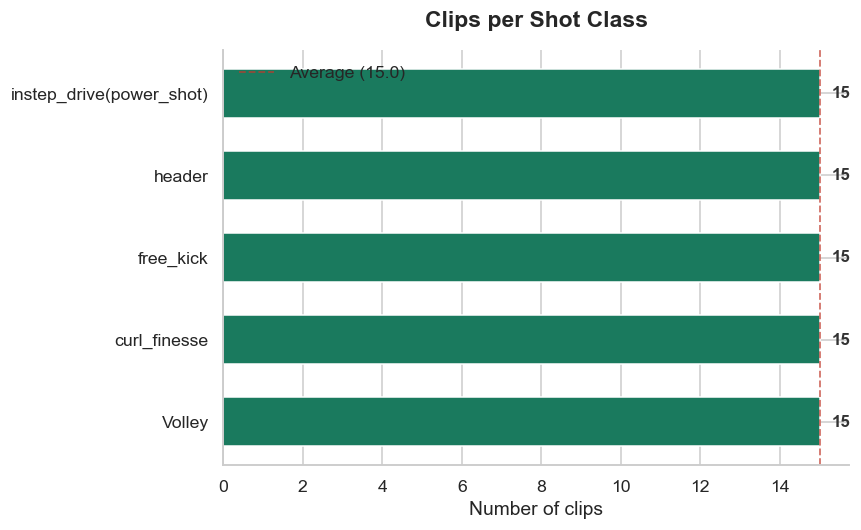

In [2]:
class_counts = df["shot_class"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(class_counts.index, class_counts.values, color=PALETTE[1], edgecolor="white", height=0.6)

for bar, val in zip(bars, class_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, str(val), va="center", fontsize=11, fontweight="bold", color="#333")

ax.set_title("Clips per Shot Class", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Number of clips")
ax.set_ylabel("")
ax.spines[["top", "right"]].set_visible(False)
ax.axvline(class_counts.mean(), color="#c0392b", linestyle="--", linewidth=1.2, alpha=0.7, label=f"Average ({class_counts.mean():.1f})")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Donut Chart, Total Dataset Composition

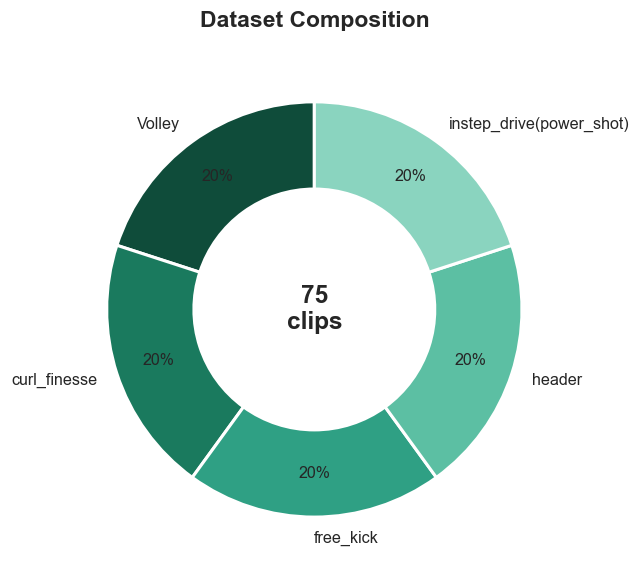

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    class_counts.values, labels=class_counts.index, autopct="%1.0f%%",
    colors=PALETTE, startangle=90, wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
    pctdistance=0.79, textprops={"fontsize": 10.5}
)
ax.text(0, 0, f"{class_counts.sum()}\nclips", ha="center", va="center", fontsize=16, fontweight="bold")
ax.set_title("Dataset Composition", fontsize=15, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()